# 04 · Métricas de Qualidade

Implementação do slide **"Pausa para Código"** de Métricas: acurácia, acurácia balanceada, precisão, recall, F1, AUC-ROC, matriz de confusão (classificação) e MAE/MSE/RMSE/R² (regressão).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import matplotlib.pyplot as plt

from distance_models import KNNClassifier, KNNRegressor
from datasets_utils import load_classification_dataset, load_regression_dataset
from metrics_utils import classification_report_dict, regression_report_dict, confusion, results_table
from viz import plot_confusion_matrix, plot_residuals

plt.rcParams['figure.facecolor'] = 'white'

## 1. Métricas de Classificação (Breast Cancer)

In [2]:
X_train, X_test, y_train, y_test, target_names = load_classification_dataset('breast_cancer')

clf = KNNClassifier(k=7, weighting='distance')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

relatorio = classification_report_dict(y_test, y_pred, y_proba, average='binary', pos_label=1)
for metrica, valor in relatorio.items():
    print(f'{metrica:22s}: {valor:.4f}')

Acurácia              : 0.9649
Acurácia balanceada   : 0.9531
Precisão              : 0.9469
Recall                : 1.0000
F1-score              : 0.9727
AUC-ROC               : 0.9933


### Matriz de confusão

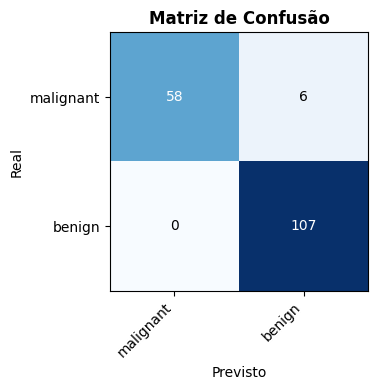

In [3]:
cm, labels = confusion(y_test, y_pred)
nomes = [target_names[l] for l in labels] if target_names is not None else labels
fig, ax = plt.subplots(figsize=(4.5,4))
plot_confusion_matrix(cm, nomes, ax=ax)
plt.tight_layout(); plt.show()

### Por que "acurácia" sozinha engana em dados desbalanceados

Simulação: um dataset artificialmente desbalanceado (95% de uma classe), onde um modelo "preguiçoso" (sempre prevê a classe majoritária) tem acurácia alta mas é inútil.

In [4]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

y_real = np.array([0]*95 + [1]*5)
y_preguicoso = np.zeros(100)  # sempre prevê a classe 0

print('Acurácia:', accuracy_score(y_real, y_preguicoso))
print('Acurácia balanceada:', balanced_accuracy_score(y_real, y_preguicoso))
print('F1-score (classe 1):', f1_score(y_real, y_preguicoso, pos_label=1, zero_division=0))
print('\n-> Acurácia de 95% parece ótima, mas o modelo nunca acerta a classe rara. Acurácia balanceada e F1 mostram isso.')

Acurácia: 0.95
Acurácia balanceada: 0.5
F1-score (classe 1): 0.0

-> Acurácia de 95% parece ótima, mas o modelo nunca acerta a classe rara. Acurácia balanceada e F1 mostram isso.


## 2. Métricas de Regressão (Diabetes)

In [5]:
Xr_train, Xr_test, yr_train, yr_test = load_regression_dataset('diabetes')

reg = KNNRegressor(k=9, weighting='distance')
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

relatorio_reg = regression_report_dict(yr_test, yr_pred)
for metrica, valor in relatorio_reg.items():
    print(f'{metrica:6s}: {valor:.4f}')

MAE   : 44.1494
MSE   : 3164.7670
RMSE  : 56.2563
R²    : 0.4137


### Visualizando os resíduos

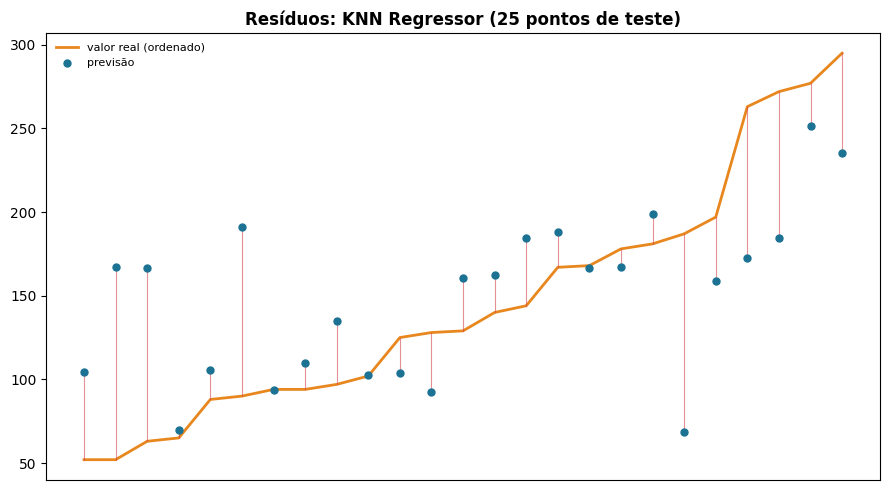

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
# amostra menor só para o gráfico não ficar poluído
idx = np.random.RandomState(0).choice(len(yr_test), size=25, replace=False)
plot_residuals(np.array(yr_test)[idx], yr_pred[idx], ax=ax, title='Resíduos: KNN Regressor (25 pontos de teste)')
plt.tight_layout(); plt.show()

### MAE vs. RMSE: sensibilidade a outliers

Demonstração simples: um único erro grande infla o RMSE muito mais que o MAE.

In [7]:
y_true_demo = np.array([10, 12, 9, 11, 10])
y_pred_sem_outlier = np.array([11, 11, 10, 10, 11])
y_pred_com_outlier = np.array([11, 11, 10, 10, 30])  # um erro grande

for nome, pred in [('sem outlier', y_pred_sem_outlier), ('com outlier', y_pred_com_outlier)]:
    rel = regression_report_dict(y_true_demo, pred)
    print(f"{nome:12s} -> MAE: {rel['MAE']:.2f}  |  RMSE: {rel['RMSE']:.2f}")

sem outlier  -> MAE: 1.00  |  RMSE: 1.00
com outlier  -> MAE: 4.80  |  RMSE: 8.99


---
**Pronto para o FEMa:** `classification_report_dict` e `regression_report_dict` (em `src/metrics_utils.py`) recebem apenas `y_true`/`y_pred`/`y_proba` — funcionam com qualquer modelo, inclusive o `FEMaClassifier`/`FEMaRegressor` futuros.